# House Price Prediction using Machine Learning

## Project Overview

This project aims to predict house prices using machine learning techniques. The model is trained on housing-related features such as area, bedrooms, bathrooms, and other property attributes to estimate house prices accurately.

## Importing Libraries and Loading Dataset

## Dataset Description

The dataset contains housing-related features such as area, number of bedrooms, bathrooms, stories, parking availability, and furnishing status. The target variable is house price, which will be predicted using machine learning techniques.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Housing.csv.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Dataset Information


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Missing Values Analysis


In [5]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Dataset Summary

In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 545
Number of Columns: 13


## Statistical Summary

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Data Visualization


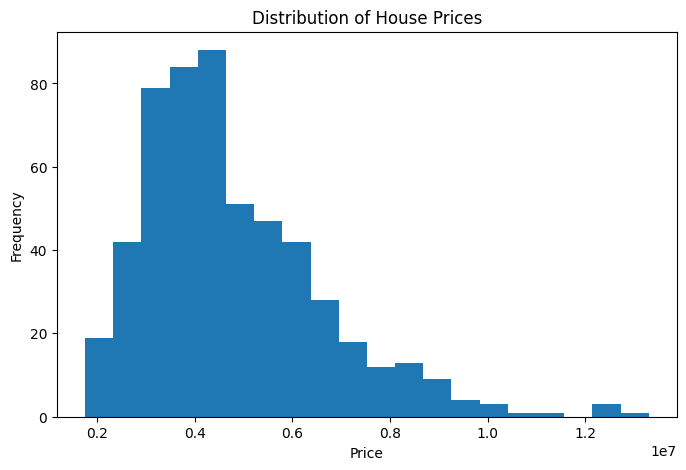

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Observation

Most houses are concentrated in the lower and medium price ranges. Only a small number of houses have very high prices, indicating that the dataset contains a few premium properties.

## Correlation Analysis

In [9]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


## Correlation Heatmap

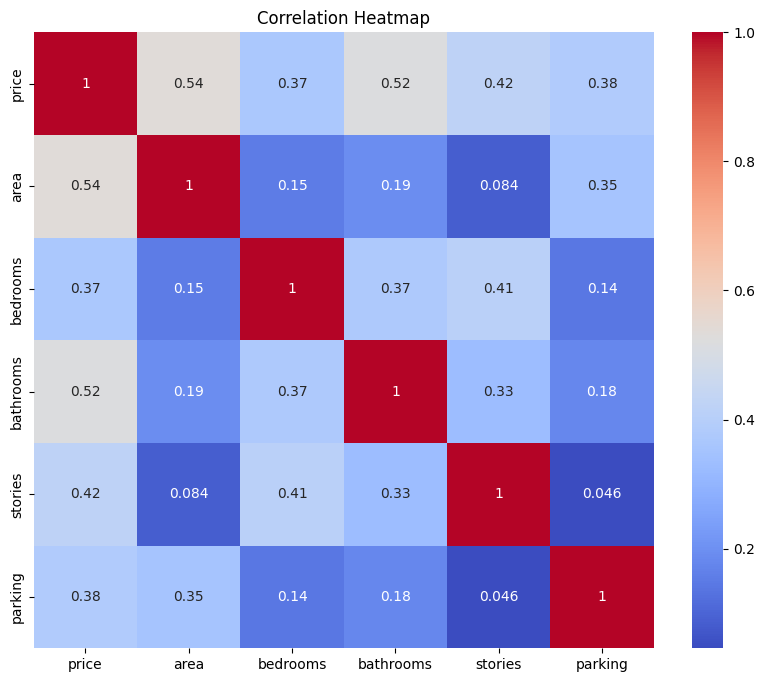

In [10]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

### Observation

The correlation analysis shows that area has the strongest relationship with house price (0.536), followed by bathrooms and stories. This indicates that larger houses with more amenities generally have higher prices.

## Data Preprocessing

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Encoding Categorical Variables

In [12]:
df.replace({
    'yes': 1,
    'no': 0,
    'furnished': 2,
    'semi-furnished': 1,
    'unfurnished': 0
}, inplace=True)

df.head()

/tmp/ipykernel_398/2068318111.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


## Feature Selection

In [13]:
X = df.drop('price', axis=1)
y = df['price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 12)
Target Shape: (545,)


## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 12)
Testing Data: (109, 12)


## Building the Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## House Price Prediction

In [16]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[5203691.70963178 7257004.02115475 3062828.59668171 4559591.65374424
 3332932.30559782]


## Model Evaluation

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 979679.6912959901
RMSE: 1331071.4167895108
R² Score: 0.6494754192267803


### Evaluation Results

The Linear Regression model achieved an R² Score of 0.65, indicating that approximately 65% of the variation in house prices can be explained by the selected features. The model demonstrated a reasonable predictive performance and can be used for house price estimation.

In [18]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.6854429472843788
Test R²: 0.6494754192267803


### Model Performance

The Linear Regression model achieved a Training R² Score of 0.685 and a Testing R² Score of 0.649. Since both values are close, the model demonstrates good generalization and does not exhibit significant overfitting.

## Actual vs Predicted Prices

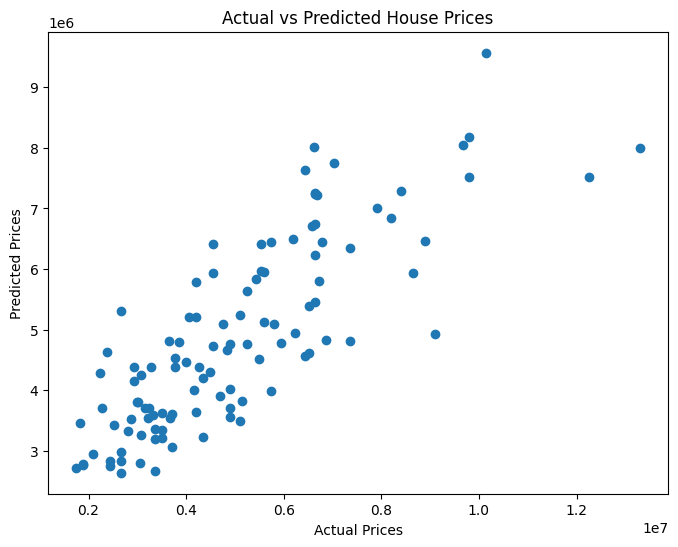

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict house prices based on various housing features. After preprocessing the data and training the model, an R² Score of 0.65 was achieved on the test dataset. The results indicate that the model can reasonably estimate house prices and demonstrates good generalization without significant overfitting. This project highlights the application of machine learning in real estate price prediction.